In [49]:
!pip install gymnasium
!pip install numpy
!pip install torch
!pip install diffusers
!pip install git+https://github.com/openai/CLIP.git
!pip install sentence_transformers
!pip install stable_baselines3
!pip install opencv-python

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-8o27gv4x
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-8o27gv4x
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [3]:
from diffusers import StableDiffusionPipeline
from transformers import AutoFeatureExtractor
import torch
from diffusers.models import AutoencoderKL
from PIL import Image
import numpy as np
import torchvision.transforms as transforms

# Load the Stable Diffusion pipeline
vae = AutoencoderKL.from_pretrained("stabilityai/sdxl-vae")

# Ensure the model is in evaluation mode
vae.eval()


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

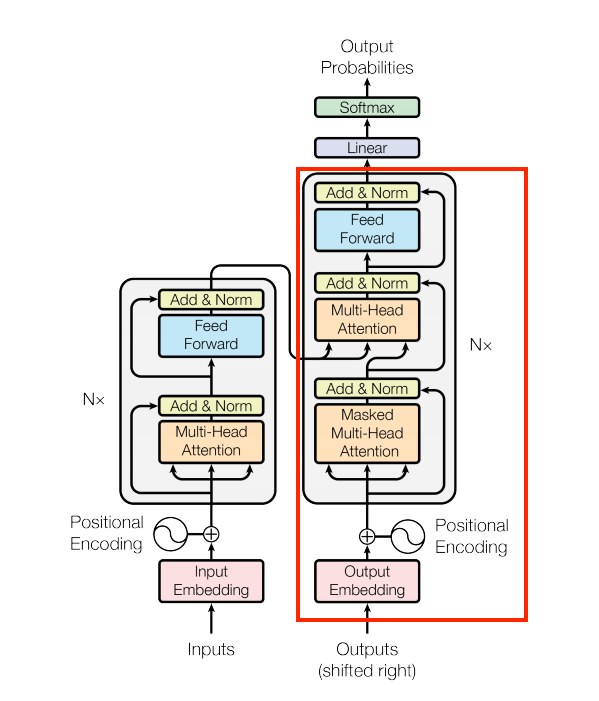

In [4]:
image = Image.open("drive/MyDrive/Transformers Tutorial/Images/Decoder.png").convert("RGB")
image

In [7]:
import torchvision.transforms as transforms

# Step 3: Preprocess the image manually
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1] range as expected by the model
    ])
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension and move to GPU
    return image_tensor

# Preprocessed image tensor
image_tensor = preprocess_image(image)
image_tensor

tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]])

In [9]:
# Step 4: Encode the image to latent space
with torch.no_grad():
    latent = vae.encode(image_tensor).latent_dist.mean
    print(latent)

tensor([[[[18.4985, 18.1034, 16.5443,  ..., 16.6702, 18.3662, 19.1027],
          [17.0071, 15.2939, 16.3104,  ..., 16.3666, 16.6282, 17.7876],
          [17.0751, 16.1111, 16.4734,  ..., 16.3432, 16.2616, 17.8811],
          ...,
          [17.0985, 15.9835, 16.4471,  ..., 16.2554, 16.1699, 17.7794],
          [16.3960, 16.6880, 16.1545,  ..., 16.2522, 16.1708, 18.5364],
          [18.9511, 18.8235, 18.4272,  ..., 18.4269, 18.8016, 17.7174]],

         [[-2.2597, -1.9462, -2.2387,  ..., -3.1718, -0.0298,  5.0541],
          [ 0.1023, -0.0356,  1.1191,  ...,  1.5949,  2.6738,  5.3742],
          [ 0.3799,  1.5388,  0.7039,  ...,  1.1265,  1.9430,  5.3558],
          ...,
          [ 0.2101,  0.5965,  0.8452,  ...,  1.1093,  1.9779,  5.4247],
          [ 0.8872,  3.2160,  0.6356,  ...,  1.3166,  1.5960,  4.9786],
          [ 4.8871,  4.0101,  4.5208,  ...,  4.6268,  4.4397,  4.2555]],

         [[ 8.8769, -1.0398,  2.2535,  ...,  2.6875, -1.0962,  7.7829],
          [ 9.4862,  4.3547,  

In [12]:
print(f"OG Image shape: {np.array(image).shape}")
print(f"Latent space representation shape: {latent.shape}")

OG Image shape: (701, 599, 3)
Latent space representation shape: torch.Size([1, 4, 64, 64])


In [13]:
# Step 5: Decode the latent space back to image
with torch.no_grad():
    reconstructed_image = vae.decode(latent)

# Convert the output tensor back to an image
def postprocess_image(image_tensor):
    image_tensor = (image_tensor / 2 + 0.5).clamp(0, 1)  # Rescale to [0, 1]
    image_tensor = image_tensor.permute(0, 2, 3, 1)  # Reorder dimensions
    image_numpy = image_tensor.cpu().numpy()
    return Image.fromarray((image_numpy[0] * 255).astype(np.uint8))

# Reconstructed image from latent space
reconstructed_image = postprocess_image(reconstructed_image.sample)
reconstructed_image.show()

In [24]:
# !pip install sentence_transformers
from sentence_transformers import SentenceTransformer
import numpy as np

sentence_encoder = SentenceTransformer("all-MiniLM-L6-v2")

husky_encoded = sentence_encoder.encode("a husky", normalize_embeddings=True)
golden_encoded = sentence_encoder.encode("a cat", normalize_embeddings=True)
print(np.dot(husky_encoded, golden_encoded.T))

0.3599347
Cosine similarity between husky and car: 0.35993462800979614


In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np
class LabelSimilarityModel():
  def __init__(self, model_name = "all-MiniLM-L6-v2"):
    self.sentence_encoder = SentenceTransformer(model_name)

  def calc_similarity_percentage(self, label1, label2):
    label1_embedded = self.sentence_encoder.encode(label1, normalize_embeddings=True)
    label2_embedded = self.sentence_encoder.encode(label2, normalize_embeddings=True)
    return np.dot(label1_embedded, label2_embedded.T)

/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [20]:
from diffusers.models import AutoencoderKL
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
import torch

class ImageConverter():
  def __init__(self, vae_model = "stabilityai/sdxl-vae"):
    self.vae = AutoencoderKL.from_pretrained(vae_model)

    # Ensure the model is in evaluation mode
    self.vae.eval()

  # Step 3: Preprocess the image manually
  def preprocess_image(self, image):
      transform = transforms.Compose([
          transforms.Resize((512, 512)),
          transforms.ToTensor(),
          transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1] range as expected by the model
      ])
      image_tensor = transform(image).unsqueeze(0)  # Add batch dimension and move to GPU
      return image_tensor

  # Convert the output tensor back to an image
  def postprocess_image(self, image_tensor):
      image_tensor = (image_tensor / 2 + 0.5).clamp(0, 1)  # Rescale to [0, 1]
      image_tensor = image_tensor.permute(0, 2, 3, 1)  # Reorder dimensions
      image_numpy = image_tensor.cpu().numpy()
      return Image.fromarray((image_numpy[0] * 255).astype(np.uint8))

  def image_to_latent_space(self, image):

    # Preprocessed image tensor
    image_tensor = self.preprocess_image(image)

    # Step 4: Encode the image to latent space
    with torch.no_grad():
        latent = self.vae.encode(image_tensor).latent_dist.mean
        return latent # Reduces size of image to 1% of it's original size.

  def latent_space_to_image(self, latent_space):
    # Step 5: Decode the latent space back to image
    with torch.no_grad():
        reconstructed_image = self.vae.decode(latent_space)

    reconstructed_image = self.postprocess_image(reconstructed_image.sample)
    return reconstructed_image

In [44]:
import clip
from torch import no_grad
from torch import stack
from torch import cat
from PIL import Image
import os
import numpy as np

class CLIP_Classifier:
    def __init__(self, device):

        # Load the model
        self.device = device
        self.model, self.preprocess = clip.load('RN50', self.device)

    def predict(self, noise_imgs, target_class, classes, top):
        image_input = []
        for image in noise_imgs:
           image_input.append(self.preprocess(image))
        # Prepare the inputs
        image_input = stack(image_input).to(self.device)
        # image_input = self.preprocess(images).unsqueeze(0).to(self.device)
        text_inputs = cat([clip.tokenize(f"a photo of a {c}") for c in classes]).to(self.device)

        if top > len(classes):
            print("The number of top predictions you want is higher than the number of classes provided.")
            return []

        # Calculate features
        with no_grad():
            image_features = self.model.encode_image(image_input)
            text_features = self.model.encode_text(text_inputs)

        # Pick the top 5 most similar labels for the image
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarities = (100.0 * image_features @ text_features.T).squeeze(0)

        per_image_predictions = []
        for similarity in similarities:
          values, indices = similarity.softmax(dim=-1).topk(top)
          predictions = []
          for value, index in zip(values, indices):
            predictions.append(("", classes[index], value.item()))
          per_image_predictions.append(predictions)

        target_confs = []
        for similarity in similarities:
           values, indices = similarity.softmax(dim=-1).topk(len(classes))
           for value, index in zip(values, indices):
              if classes[index] == target_class:
                 target_confs.append(value.item())
        return per_image_predictions, np.array(target_confs).mean()

    def predict_single(self, noise_img, target_class, classes, top):
        # Prepare the inputs
        image = noise_img
        image_input = self.preprocess(image).unsqueeze(0).to(self.device)
        text_inputs = cat([clip.tokenize(f"a photo of a {c}") for c in classes]).to(self.device)

        if top > len(classes):
            print("The number of top predictions you want is higher than the number of classes provided.")
            return []

        # Calculate features
        with no_grad():
            image_features = self.model.encode_image(image_input)
            text_features = self.model.encode_text(text_inputs)

        # Pick the top 5 most similar labels for the image
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        values, indices = similarity[0].topk(top)

        # Print the result
        # print("\nTop predictions:\n")
        target_pred = 0
        predictions = []
        for value, index in zip(values, indices):
            predictions.append(("", classes[index], value.item()))

            if classes[index] == target_class:
               target_pred = value.item()
            # print(f"{classes[index]:>16s}: {100 * value.item():.2f}%")
            # print("value: " + str(value.item()))
        return predictions, target_pred

In [67]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from PIL import Image
import os
import datetime
from google.colab.patches import cv2_imshow
import cv2

class AdvEnv(gym.Env):
    def __init__(self, classifier_model, image_converter, label_similarity_model, args, labels,  logPath = '../AdvOutput/rewards.log'):
        super(AdvEnv, self).__init__()

        self.classifier = classifier_model
        self.labels = labels
        self.true_class = args.true_class # True class
        self.negative_labels = args.negative_labels # Labels to avoid.
        self.target = args.target_class # Target class

        self.input_image_folder = args.input_image_folder
        self.output_image_folder = args.output_image_folder
        self.ground_truth_imgs = Image.open(self.input_image_folder)

        self.image_converter = image_converter # Converts image to and from latent space.
        self.label_similarity_model = label_similarity_model # Compares labels to see if they are more or less similar.
        self.similarity_threshold = args.similarity_threshold # Threshold to determine whether reward is penalty or incentive.

        self.state = self.image_converter.image_to_latent_space(Image.open(self.input_image_folder)) # Initial state.
        self.observation_space_shape = self.state.shape
        self.action_space_shape = self.state.shape

        if self.target not in self.labels:
            self.labels.append(self.target)

        self.total_reward = 0
        self.epochs = 0

        # Define action and observation spaces
        self.action_space = spaces.Box(low=-10, high=10, shape=(self.observation_space_shape), dtype=np.float32)  # Define space of allowable feature grid modifications
        self.observation_space = spaces.Box(low=-255, high=255, shape=self.action_space_shape, dtype=np.uint8) # Define state representation (e.g., feature grid, image)

    def reset(self, seed=0):
        super().reset(seed=seed)
        self.ground_truth_imgs = Image.open(self.input_image_folder) # Reopen original image.
        latent_space = self.image_converter.image_to_latent_space(self.ground_truth_imgs) # Convert original image to latent space.
        self.state = latent_space # State is used for reference by agent.
        return (latent_space, {}) # Return latent space to reset observation space.

    def calc_mse(self, og_imgs, rendered_imgs):
        squared_diff = (og_imgs - rendered_imgs) ** 2
        mse = np.mean(squared_diff)

        # Returns the maximum MSE. Penalize the agent for high mse score.
        return mse.max()

    def get_reward(self, advImage, predicted_label, predicted_conf, target_conf):
        # mse = self.calc_mse(self.ground_truth_imgs, advImage)
        returned_reward = 0

        # Calculates similarity between predicted label and our target label.
        similarity_percentage = self.label_similarity_model.calc_similarity_percentage(self.target, predicted_label)

        # If predicted label is not all that similar to our target label, penalize agent. Otherwise, reward the agent.
        if(similarity_percentage < .5):
          returned_reward -= similarity_percentage * predicted_conf * 10
        else:
          returned_reward += similarity_percentage * predicted_conf

        returned_reward += target_conf # Reward the agent for confidence in target class.
        return returned_reward

    def pred_labels(self):
        adv_img = self.image_converter.latent_space_to_image(self.state)
        predictions, target_pred = self.classifier.predict_single(adv_img, self.target, self.labels, top = 1)

        top1_label = predictions[0][1] # Grab top 1 predicted label
        top1_conf = predictions[0][2] # Grab top 1 confidence.

        reward = self.get_reward(adv_img, top1_label, top1_conf, target_pred)

        info = {
            "Target" : self.target,
            "Target Conf" : target_pred,
            "Predicted" : top1_label,
            "Top 1 Confidence" : top1_conf,
            "Epochs" : self.epochs
        }
        return adv_img, reward, info

    def step(self, action):
        # Modify feature grid based on action
        self.state +=  action # Apply action to feature grid
        truncated, info = False, {}

        image, reward, info = self.pred_labels()

        self.total_reward += reward

        # Determine if episode is done
        done = False
        if reward < 0:
          done = True
          print("RESETTING ENVIRONMENT. AGENT FAILED.")

        self.epochs += 1

        print("info: " + str(info))
        print("Total Reward: " + str(self.total_reward))

        return self.state, reward, done, truncated, info

    def render(self):
        cv2_imshow(cv2.cvtColor(np.array(self.image_converter.latent_space_to_image(self.state)), cv2.COLOR_BGR2RGB))
        cv2.waitKey(10)
      # cv2_imshow()

    def close(self):
        self.log.close()

In [68]:
class ArgumentClass():
  def __init__(self):
    self.clip_device = "cpu"
    self.input_image_folder = "drive/MyDrive/Thesis Folder/Inputs/0173.jpg"
    self.output_image_folder = "./"
    self.true_class = "banana"
    self.target_class = "slug"
    self.negative_labels = []
    self.similarity_threshold = 0.5

import argparse

parser = argparse.ArgumentParser(description="Reinforcement learning approach for generating adversarial noise.")
parser.clip_device = "cuda:0"
# parser.add_argument("--clip_device", default="cuda:0", type=str, help="Which device to execute clip on.")
parser.input_image_folder = "drive/MyDrive/Thesis Folder/Inputs/0173.jpg"
parser.output_image_folder = "./"
# parser.add_argument("--input_image_folder", default="../BananaScene/Output/", type=str, help="Path to the images we will use to generate a 3D model using NeRF.")
# parser.add_argument("--output_image_folder", default="../BananaScene/AdvOut/", type=str, help="Folder to output generated images to.")
parser.true_class = "banana"
parser.target_class = "slug"
parser.negative_labels = []
# parser.add_argument("--true_class", default="banana", type=str, help="True class of the object.")
# parser.add_argument("--target_class", default="slug", type=str, help="Target class to produce adversarial noise to target.")
# parser.add_argument('-l','--negative_labels', nargs='+', help='List of class labels to tell the agent to avoid predicting.')

# Hyperparameters
# parser.n_steps = 32
# parser.batch_size = 32
# parser.add_argument("--n_steps", default=32, type=int, help="Number of steps reinforcement agent can take.")
# parser.add_argument("--batch_size", default=32, type=int, help="Reinforcement learning batch size.")
# parser.add_argument("--max_grad_norm", default=.00001, type=float, help="Reinforcement maximum gradient norm. NOTE: If value is set too high, it may result in gradient explosion.")
# parser.add_argument('--theta_0', default= 100, type=int, help='Weight for target confidence in reward equation.')
# parser.add_argument("--theta_1", default=-1, type=int, help="Weight for true confidence in reward equation.")
# parser.add_argument("--theta_2", default=-0.00005, type=float, help="Weight for MSE influence in reward equation.")

parser.similarity_threshold = 0.5
# parser.add_argument("--similarity_threshold", default=0.5, type=float, help="Threshold used in reward function. Default is 50%, if less than 50% then the similarity metric will be a penalty, greater will be reward.")

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


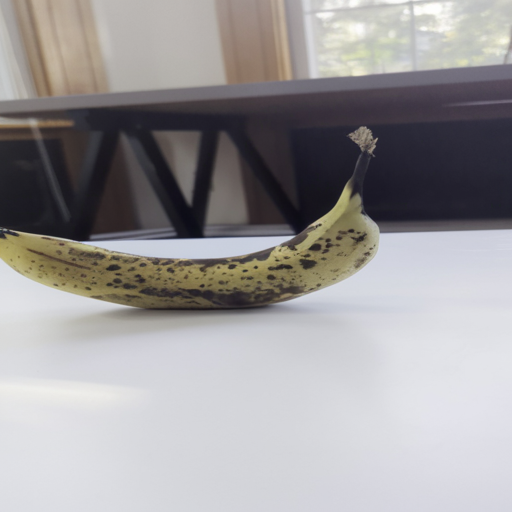

In [69]:
import requests
args = ArgumentClass()

pretrained_model = CLIP_Classifier(args.clip_device)

# Download the ImageNet labels file
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
response = requests.get(url)
labels = response.json()

image_converter = ImageConverter()
label_similarity_model = LabelSimilarityModel()

env = AdvEnv(pretrained_model, image_converter, label_similarity_model, args, labels)

# cv2_imshow(cv2.cvtColor(np.array(image_converter.latent_space_to_image(env.state)), cv2.COLOR_BGR2RGB))

In [70]:
from stable_baselines3 import PPO

# Create RL agent
model = PPO('MlpPolicy', env, device='cpu')
# Train the agent
# Evaluate the trained agent
episode_reward = 0
obs, info = env.reset()
_states = None

while True:
    model.learn(total_timesteps=1)
    # action, _states = model.predict(obs)
    # obs, rewards, dones, truncated, info = env.step(action)
    env.render()

RESETTING ENVIRONMENT. AGENT FAILED.
info: {'Target': 'slug', 'Target Conf': 0, 'Predicted': 'water snake', 'Top 1 Confidence': 0.11971938610076904, 'Epochs': 0}
Total Reward: -0.3919643728676192
info: {'Target': 'slug', 'Target Conf': 0, 'Predicted': 'balance beam', 'Top 1 Confidence': 0.10612857341766357, 'Epochs': 1}
Total Reward: -0.38718442215449844


KeyboardInterrupt: 